In [1]:
import torch

print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("⚠️ GPU not available")

PyTorch version: 2.11.0+cu130
GPU available: True
GPU: Tesla T4


In [2]:
!pip install -q diffusers transformers accelerate safetensors

In [3]:
import diffusers
import transformers
import accelerate
import torch

print("Diffusers:", diffusers.__version__)
print("Transformers:", transformers.__version__)
print("Accelerate:", accelerate.__version__)
print("PyTorch:", torch.__version__)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "Not Available")

Diffusers: 0.40.0
Transformers: 5.17.0
Accelerate: 1.15.0
PyTorch: 2.11.0+cu130
GPU: Tesla T4


In [4]:
import torch
from diffusers import StableDiffusionPipeline

model_id = "runwayml/stable-diffusion-v1-5"

pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16
)

pipe = pipe.to("cuda")

print("Stable Diffusion model loaded successfully!")
print("Device:", pipe.device)

/usr/local/lib/python3.13/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Stable Diffusion model loaded successfully!
Device: cuda:0


  0%|          | 0/30 [00:00<?, ?it/s]

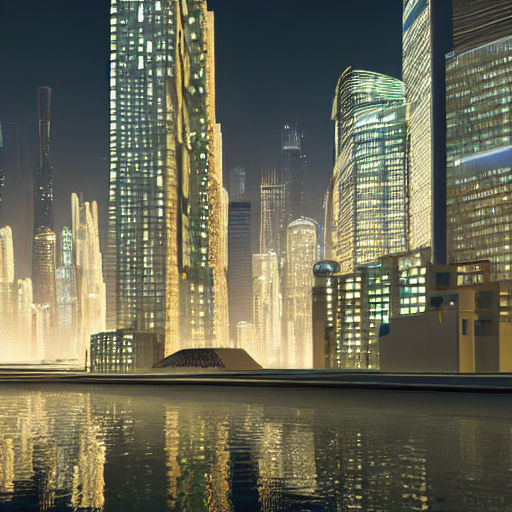

In [5]:
import torch
from IPython.display import display

prompt = """
A futuristic smart city at night, glowing skyscrapers, autonomous flying vehicles,
beautiful modern architecture, cinematic lighting, highly detailed, realistic,
professional digital art, 4K
"""

negative_prompt = """
blurry, low quality, distorted, deformed, ugly, duplicate objects,
text, watermark, logo
"""

image = pipe(
    prompt=prompt,
    negative_prompt=negative_prompt,
    num_inference_steps=30,
    guidance_scale=7.5,
    height=512,
    width=512
).images[0]

display(image)

In [6]:
import os

os.makedirs("outputs", exist_ok=True)

image_path = "outputs/futuristic_smart_city.png"
image.save(image_path)

print("Image saved successfully!")
print("Saved at:", image_path)

Image saved successfully!
Saved at: outputs/futuristic_smart_city.png


In [7]:
prompts = {
    "fantasy_castle": """
    A magnificent magical castle floating above the clouds at sunset,
    golden light, dramatic sky, fantasy environment, highly detailed,
    cinematic digital art
    """,

    "nature_landscape": """
    A peaceful mountain lake surrounded by autumn forests,
    snow-covered mountains in the background, warm morning sunlight,
    realistic landscape photography, highly detailed
    """,

    "futuristic_city": """
    A futuristic smart city at night with glowing skyscrapers,
    autonomous flying vehicles, advanced technology, cinematic lighting,
    highly detailed professional digital art
    """,

    "robot_library": """
    A cute intelligent robot exploring an ancient magical library,
    thousands of books, warm lighting, detailed environment,
    cinematic fantasy artwork
    """
}

print("Number of prompts:", len(prompts))

Number of prompts: 4


Generating: fantasy_castle


  0%|          | 0/30 [00:00<?, ?it/s]

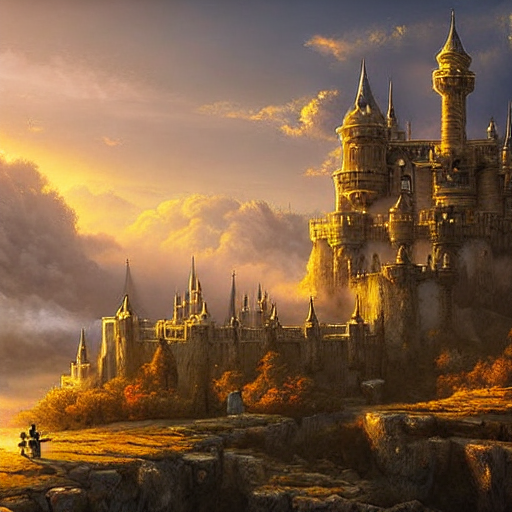

Saved: outputs/fantasy_castle.png
--------------------------------------------------
Generating: nature_landscape


  0%|          | 0/30 [00:00<?, ?it/s]

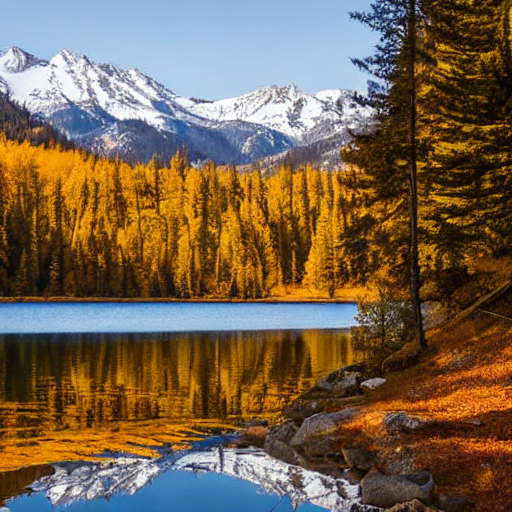

Saved: outputs/nature_landscape.png
--------------------------------------------------
Generating: futuristic_city


  0%|          | 0/30 [00:00<?, ?it/s]

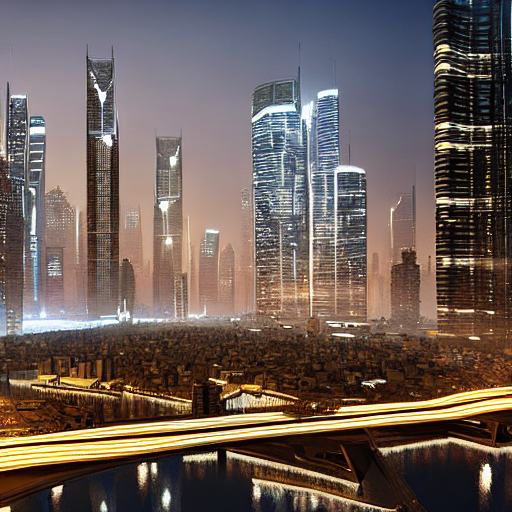

Saved: outputs/futuristic_city.png
--------------------------------------------------
Generating: robot_library


  0%|          | 0/30 [00:00<?, ?it/s]

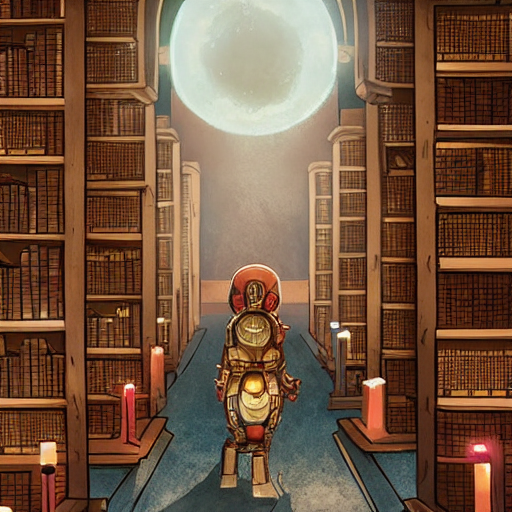

Saved: outputs/robot_library.png
--------------------------------------------------


In [8]:
import os
import torch
from IPython.display import display

os.makedirs("outputs", exist_ok=True)

negative_prompt = """
blurry, low quality, distorted, deformed, ugly, duplicate objects,
text, watermark, logo
"""

for name, prompt in prompts.items():

    print(f"Generating: {name}")

    generator = torch.Generator(device="cuda").manual_seed(42)

    result = pipe(
        prompt=prompt,
        negative_prompt=negative_prompt,
        num_inference_steps=30,
        guidance_scale=7.5,
        height=512,
        width=512,
        generator=generator
    )

    generated_image = result.images[0]

    output_path = f"outputs/{name}.png"
    generated_image.save(output_path)

    display(generated_image)

    print(f"Saved: {output_path}")
    print("-" * 50)

In [9]:
import os
import torch
from IPython.display import display

def generate_image(
    prompt,
    filename,
    negative_prompt="blurry, low quality, distorted, deformed, text, watermark, logo",
    steps=30,
    guidance=7.5,
    width=512,
    height=512,
    seed=42
):
    """
    Generate an image from a text prompt using Stable Diffusion.
    """

    generator = torch.Generator(device="cuda").manual_seed(seed)

    result = pipe(
        prompt=prompt,
        negative_prompt=negative_prompt,
        num_inference_steps=steps,
        guidance_scale=guidance,
        width=width,
        height=height,
        generator=generator
    )

    image = result.images[0]

    os.makedirs("outputs", exist_ok=True)

    output_path = f"outputs/{filename}.png"
    image.save(output_path)

    display(image)

    print(f"Prompt: {prompt.strip()}")
    print(f"Seed: {seed}")
    print(f"Steps: {steps}")
    print(f"Guidance Scale: {guidance}")
    print(f"Resolution: {width} × {height}")
    print(f"Saved to: {output_path}")

    return image

  0%|          | 0/30 [00:00<?, ?it/s]

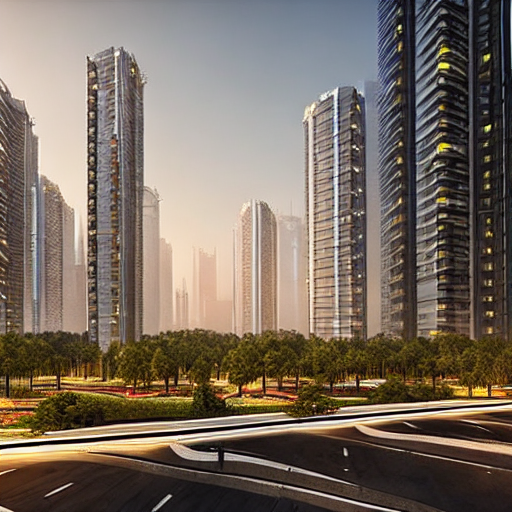

Prompt: A futuristic Indian city with modern skyscrapers,
green technology, clean streets, autonomous vehicles,
sunset, cinematic lighting, highly detailed digital art
Seed: 42
Steps: 30
Guidance Scale: 7.5
Resolution: 512 × 512
Saved to: outputs/test_generation.png


In [10]:
test_prompt = """
A futuristic Indian city with modern skyscrapers,
green technology, clean streets, autonomous vehicles,
sunset, cinematic lighting, highly detailed digital art
"""

generated_image = generate_image(
    prompt=test_prompt,
    filename="test_generation"
)


Generating with guidance scale = 5.0


  0%|          | 0/30 [00:00<?, ?it/s]

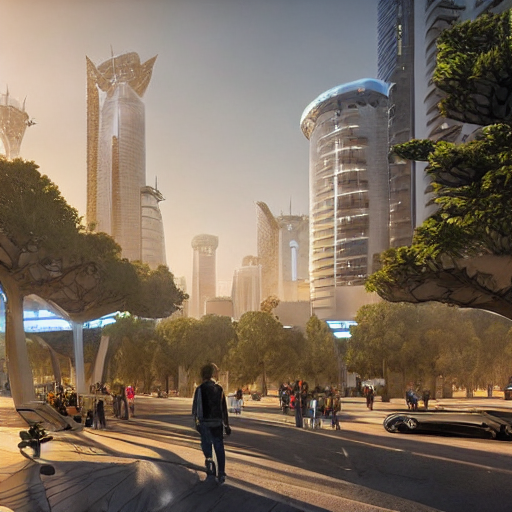

Prompt: A futuristic smart city with sustainable green buildings,
solar panels, autonomous electric vehicles, people walking,
beautiful sunset, cinematic lighting, highly detailed digital art
Seed: 42
Steps: 30
Guidance Scale: 5.0
Resolution: 512 × 512
Saved to: outputs/smart_city_guidance_5_0.png

Generating with guidance scale = 7.5


  0%|          | 0/30 [00:00<?, ?it/s]

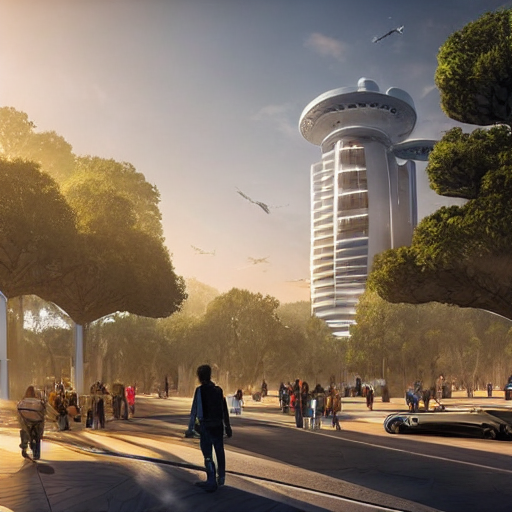

Prompt: A futuristic smart city with sustainable green buildings,
solar panels, autonomous electric vehicles, people walking,
beautiful sunset, cinematic lighting, highly detailed digital art
Seed: 42
Steps: 30
Guidance Scale: 7.5
Resolution: 512 × 512
Saved to: outputs/smart_city_guidance_7_5.png

Generating with guidance scale = 10.0


  0%|          | 0/30 [00:00<?, ?it/s]

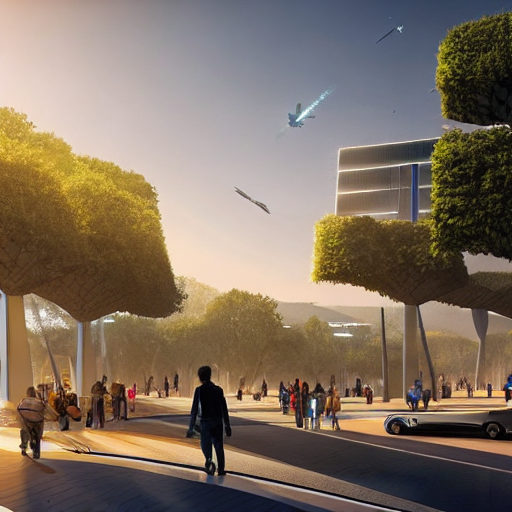

Prompt: A futuristic smart city with sustainable green buildings,
solar panels, autonomous electric vehicles, people walking,
beautiful sunset, cinematic lighting, highly detailed digital art
Seed: 42
Steps: 30
Guidance Scale: 10.0
Resolution: 512 × 512
Saved to: outputs/smart_city_guidance_10_0.png


In [11]:
experiment_prompt = """
A futuristic smart city with sustainable green buildings,
solar panels, autonomous electric vehicles, people walking,
beautiful sunset, cinematic lighting, highly detailed digital art
"""

guidance_values = [5.0, 7.5, 10.0]

for guidance in guidance_values:

    filename = f"smart_city_guidance_{str(guidance).replace('.', '_')}"

    print(f"\nGenerating with guidance scale = {guidance}")

    generate_image(
        prompt=experiment_prompt,
        filename=filename,
        steps=30,
        guidance=guidance,
        width=512,
        height=512,
        seed=42
    )

  0%|          | 0/40 [00:00<?, ?it/s]

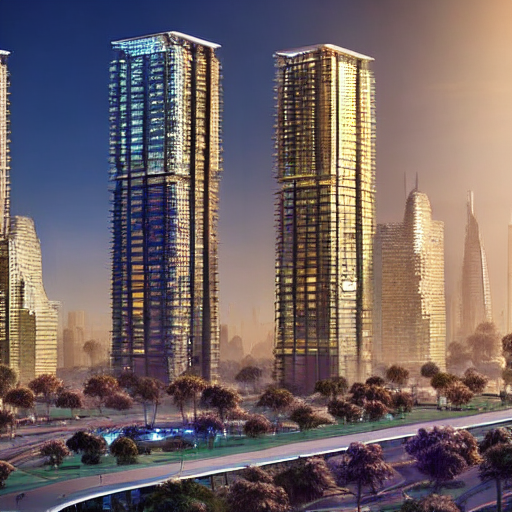

Prompt: A breathtaking futuristic smart city in India at sunset,
modern sustainable skyscrapers, rooftop gardens,
autonomous electric vehicles, clean streets,
people walking through a beautiful urban plaza,
warm golden sunlight, cinematic composition,
photorealistic, highly detailed, professional concept art
Seed: 123
Steps: 40
Guidance Scale: 7.5
Resolution: 512 × 512
Saved to: outputs/final_showcase.png


In [12]:
final_prompt = """
A breathtaking futuristic smart city in India at sunset,
modern sustainable skyscrapers, rooftop gardens,
autonomous electric vehicles, clean streets,
people walking through a beautiful urban plaza,
warm golden sunlight, cinematic composition,
photorealistic, highly detailed, professional concept art
"""

final_image = generate_image(
    prompt=final_prompt,
    filename="final_showcase",
    steps=40,
    guidance=7.5,
    width=512,
    height=512,
    seed=123
)

In [13]:
%%writefile requirements.txt

torch
diffusers
transformers
accelerate
safetensors
Pillow

Writing requirements.txt


In [14]:
%%writefile .gitignore

__pycache__/
*.pyc
.ipynb_checkpoints/
.env
venv/

Writing .gitignore


In [15]:
%%writefile README.md

# PRODIGY TASK 02 - Image Generation with Pre-trained Models

## Project Overview

This project demonstrates text-to-image generation using a pre-trained Stable Diffusion model.

The system accepts a natural language text prompt and generates a corresponding image using a diffusion-based generative AI model.

## Objective

The objective of this project is to explore how pre-trained generative AI models can transform textual descriptions into visually meaningful images.

## Model Used

- Model: Stable Diffusion v1.5
- Framework: Hugging Face Diffusers
- Programming Language: Python
- Environment: Google Colab
- Hardware: NVIDIA Tesla T4 GPU

## Technologies Used

- Python
- PyTorch
- Hugging Face Diffusers
- Transformers
- Accelerate
- Safetensors
- Pillow
- Google Colab

## How It Works

The project follows the following workflow:

Text Prompt
↓
Stable Diffusion Pipeline
↓
Text Conditioning
↓
Diffusion / Denoising Process
↓
Image Generation
↓
PNG Output

## Features

- Text-to-image generation
- Negative prompt support
- Adjustable guidance scale
- Adjustable inference steps
- Configurable image resolution
- Reproducible generation using random seeds
- Multiple prompt experiments
- Generated image saving

## Example Prompts

1. A futuristic smart city at night with glowing skyscrapers.
2. A magnificent magical castle floating above the clouds.
3. A peaceful mountain lake surrounded by autumn forests.
4. A cute intelligent robot exploring an ancient library.

## Experimental Parameters

The project experiments with:

- Guidance Scale: 5.0, 7.5, 10.0
- Inference Steps: 30-40
- Resolution: 512 × 512
- Random Seed: 42 and 123

## Output

The generated images are stored in the `outputs` directory.

## Conclusion

This project demonstrates the practical use of a pre-trained diffusion model for text-to-image generation. The experiments show how different prompts and generation parameters can influence the resulting images.

## Author

Lakshmi Varsha Thumati

B.Tech - Computer Science and Engineering (Data Science)

## Internship

Prodigy Infotech - Generative AI Internship

Task 02: Image Generation with Pre-trained Models

Writing README.md


In [16]:
import os

print("Project files:")
for item in os.listdir("."):
    print(item)

print("\nGenerated images:")
for item in os.listdir("outputs"):
    print(item)

Project files:
.config
.gitignore
requirements.txt
outputs
README.md
sample_data

Generated images:
smart_city_guidance_7_5.png
smart_city_guidance_5_0.png
futuristic_smart_city.png
fantasy_castle.png
final_showcase.png
futuristic_city.png
nature_landscape.png
robot_library.png
test_generation.png
smart_city_guidance_10_0.png


In [17]:
import shutil
import os

project_files = [
    "requirements.txt",
    ".gitignore",
    "README.md"
]

# Create a temporary project folder
os.makedirs("Prodigy_Task02_Image_Generation", exist_ok=True)

# Copy project files
for file in project_files:
    shutil.copy(file, "Prodigy_Task02_Image_Generation/")

# Copy generated images
shutil.copytree(
    "outputs",
    "Prodigy_Task02_Image_Generation/outputs",
    dirs_exist_ok=True
)

# Copy the notebook itself
notebook_path = "/content/Prodigy_Task02_Image_Generation.ipynb"

if os.path.exists(notebook_path):
    shutil.copy(
        notebook_path,
        "Prodigy_Task02_Image_Generation/"
    )

# Create ZIP
shutil.make_archive(
    "Prodigy_Task02_Image_Generation",
    "zip",
    "Prodigy_Task02_Image_Generation"
)

print("Project ZIP created successfully!")

Project ZIP created successfully!


In [18]:
from google.colab import files

files.download("Prodigy_Task02_Image_Generation.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [19]:
import os

print("Notebook files found:")
for file in os.listdir("/content"):
    if file.endswith(".ipynb"):
        print(file)

Notebook files found:


In [20]:
import os
import shutil

# Find the notebook automatically
notebooks = [
    f for f in os.listdir("/content")
    if f.endswith(".ipynb")
]

if notebooks:
    notebook = notebooks[0]
    print("Notebook found:", notebook)

    shutil.copy(
        f"/content/{notebook}",
        "Prodigy_Task02_Image_Generation/"
    )

    print("Notebook copied successfully!")
else:
    print("No .ipynb file found.")

No .ipynb file found.
